In [1]:
import os
import re
import gc
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ============================================================
# CONFIG
# ============================================================

DATA_DIR = "/Users/abhigyanseth/Projects/m5_forecasting/data/processed_data3"

MODEL_PATH = "/Users/abhigyanseth/Projects/m5_forecasting/m5_lightgbm_incremental.txt"

VALID_DAYS = 28

# Number of trees added for each chunk
TREES_PER_CHUNK = 20

# Prevent the model from becoming excessively large
MAX_TOTAL_TREES = 2000


# ============================================================
# FIND FILES
# ============================================================

files = [
    f for f in os.listdir(DATA_DIR)
    if f.endswith(".parquet")
]


def extract_number(filename):
    match = re.search(r"\d+", filename)
    return int(match.group()) if match else 0


files = sorted(files, key=extract_number)

print(f"Found {len(files)} parquet files")


# ============================================================
# FIND GLOBAL MAX DATE
# ============================================================

print("\nFinding final date...")

max_date = None

for file in files:

    path = os.path.join(DATA_DIR, file)

    dates = pd.read_parquet(
        path,
        columns=["date"]
    )

    dates["date"] = pd.to_datetime(dates["date"])

    file_max = dates["date"].max()

    if max_date is None or file_max > max_date:
        max_date = file_max

    del dates

print("Maximum date:", max_date)


# ============================================================
# VALIDATION PERIOD
# ============================================================

validation_start = (
    max_date -
    pd.Timedelta(days=VALID_DAYS - 1)
)

training_end = validation_start - pd.Timedelta(days=1)

print("\nTraining ends:", training_end)
print("Validation starts:", validation_start)
print("Validation ends:", max_date)


# ============================================================
# LIGHTGBM PARAMETERS
# ============================================================

params = {

    "objective": "regression",

    "metric": "rmse",

    "boosting_type": "gbdt",

    "learning_rate": 0.05,

    "num_leaves": 31,

    "max_depth": -1,

    "min_child_samples": 50,

    "feature_fraction": 0.8,

    "bagging_fraction": 0.8,

    "bagging_freq": 5,

    "reg_alpha": 0.1,

    "reg_lambda": 0.1,

    "verbosity": -1,

    "seed": 42
}


# ============================================================
# FEATURES
# ============================================================

DROP_COLUMNS = [
    "sales",
    "date",
    "d",
    "id"
]


CATEGORICAL_COLUMNS = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_name_1",
    "event_type_1"
]


# ============================================================
# PREPARE CHUNK
# ============================================================

def prepare_chunk(df):

    # Remove target / identifiers
    features = [
        c for c in df.columns
        if c not in DROP_COLUMNS
    ]

    X = df[features].copy()

    y = df["sales"].copy()

    # --------------------------------------------------------
    # Convert categorical columns
    # --------------------------------------------------------

    categorical_features = []

    for col in CATEGORICAL_COLUMNS:

        if col in X.columns:

            X[col] = X[col].astype("category")

            categorical_features.append(col)

    # --------------------------------------------------------
    # Reduce numerical memory
    # --------------------------------------------------------

    float_cols = X.select_dtypes(
        include=["float64"]
    ).columns

    X[float_cols] = X[float_cols].astype(
        "float32"
    )

    int_cols = X.select_dtypes(
        include=["int64"]
    ).columns

    X[int_cols] = X[int_cols].astype(
        "int32"
    )

    return X, y, features, categorical_features


# ============================================================
# TRAINING
# ============================================================

model = None

total_trees = 0

feature_names = None

categorical_features = None


print("\n======================================")
print("STARTING INCREMENTAL TRAINING")
print("======================================\n")


for i, file in enumerate(files):

    path = os.path.join(DATA_DIR, file)

    print(
        f"\n[{i + 1}/{len(files)}] "
        f"Processing {file}"
    )

    # --------------------------------------------------------
    # Load ONE chunk
    # --------------------------------------------------------

    df = pd.read_parquet(path)

    df["date"] = pd.to_datetime(df["date"])

    # --------------------------------------------------------
    # Training rows only
    # --------------------------------------------------------

    train_chunk = df[
        df["date"] <= training_end
    ].copy()

    # Nothing to train in this chunk
    if len(train_chunk) == 0:

        print("No training rows in this chunk")

        del df
        gc.collect()

        continue

    print(
        f"Training rows: {len(train_chunk):,}"
    )

    # --------------------------------------------------------
    # Prepare features
    # --------------------------------------------------------

    X, y, current_features, current_categorical = (
        prepare_chunk(train_chunk)
    )

    # Save feature information
    if feature_names is None:

        feature_names = current_features

        categorical_features = (
            current_categorical
        )

    # --------------------------------------------------------
    # LightGBM dataset
    # --------------------------------------------------------

    train_data = lgb.Dataset(
        X,
        label=y,
        feature_name=feature_names,
        categorical_feature=categorical_features,
        free_raw_data=True
    )

    # --------------------------------------------------------
    # Determine number of trees
    # --------------------------------------------------------

    remaining_trees = (
        MAX_TOTAL_TREES -
        total_trees
    )

    if remaining_trees <= 0:

        print("Maximum tree limit reached.")

        del train_data
        del X
        del y
        del train_chunk
        del df

        gc.collect()

        break

    num_rounds = min(
        TREES_PER_CHUNK,
        remaining_trees
    )

    # --------------------------------------------------------
    # Train / continue model
    # --------------------------------------------------------

    if model is None:

        print(
            f"Training first {num_rounds} trees..."
        )

        model = lgb.train(
            params,
            train_data,
            num_boost_round=num_rounds
        )

    else:

        print(
            f"Continuing model for "
            f"{num_rounds} trees..."
        )

        model = lgb.train(
            params,
            train_data,
            num_boost_round=num_rounds,
            init_model=model
        )

    total_trees += num_rounds

    print(
        f"Total trees: {total_trees}"
    )

    # --------------------------------------------------------
    # Free memory
    # --------------------------------------------------------

    del train_data
    del X
    del y
    del train_chunk
    del df

    gc.collect()


# ============================================================
# SAVE MODEL
# ============================================================

print("\n======================================")
print("TRAINING COMPLETE")
print("======================================")

print(
    f"Total trees: {total_trees}"
)

model.save_model(MODEL_PATH)

print(
    f"Model saved to: {MODEL_PATH}"
)


# ============================================================
# VALIDATION
# ============================================================

print("\n======================================")
print("VALIDATION")
print("======================================")


valid_predictions = []
valid_actual = []


for i, file in enumerate(files):

    path = os.path.join(DATA_DIR, file)

    df = pd.read_parquet(path)

    df["date"] = pd.to_datetime(df["date"])

    valid_chunk = df[
        df["date"] >= validation_start
    ].copy()

    if len(valid_chunk) == 0:

        del df
        gc.collect()

        continue

    print(
        f"Validating {file}: "
        f"{len(valid_chunk):,} rows"
    )

    X_valid, y_valid, _, _ = (
        prepare_chunk(valid_chunk)
    )

    predictions = model.predict(
        X_valid
    )

    # Demand cannot be negative
    predictions = np.maximum(
        predictions,
        0
    )

    valid_predictions.append(
        predictions
    )

    valid_actual.append(
        y_valid.to_numpy()
    )

    del X_valid
    del y_valid
    del valid_chunk
    del df

    gc.collect()


# ============================================================
# FINAL METRICS
# ============================================================

predictions = np.concatenate(
    valid_predictions
)

actual = np.concatenate(
    valid_actual
)


rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

mae = mean_absolute_error(
    actual,
    predictions
)


print("\n======================================")
print("RESULTS")
print("======================================")

print(
    f"RMSE: {rmse:.4f}"
)

print(
    f"MAE:  {mae:.4f}"
)

print(
    f"Validation rows: {len(actual):,}"
)

Found 69 parquet files

Finding final date...
Maximum date: 2016-04-24 00:00:00

Training ends: 2016-03-27 00:00:00
Validation starts: 2016-03-28 00:00:00
Validation ends: 2016-04-24 00:00:00

STARTING INCREMENTAL TRAINING


[1/69] Processing part_0.parquet
Training rows: 853,720
Training first 20 trees...
Total trees: 20

[2/69] Processing part_1.parquet
Training rows: 853,720
Continuing model for 20 trees...
Total trees: 40

[3/69] Processing part_2.parquet
Training rows: 853,720
Continuing model for 20 trees...
Total trees: 60

[4/69] Processing part_3.parquet
Training rows: 853,720
Continuing model for 20 trees...
Total trees: 80

[5/69] Processing part_4.parquet
Training rows: 853,720
Continuing model for 20 trees...
Total trees: 100

[6/69] Processing part_5.parquet
Training rows: 853,720
Continuing model for 20 trees...
Total trees: 120

[7/69] Processing part_6.parquet
Training rows: 853,720
Continuing model for 20 trees...
Total trees: 140

[8/69] Processing part_7.parquet
Tra

In [2]:
import pandas as pd
import numpy as np
import glob
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error

DATA_DIR = "/Users/abhigyanseth/Projects/m5_forecasting/data/processed_data3"
VALID_DAYS = 28

files = sorted(
    glob.glob(os.path.join(DATA_DIR, "*.parquet")),
    key=lambda x: int(os.path.basename(x).split("_")[-1].split(".")[0])
)

# Find the overall latest date
latest_date = None

for f in files:
    df = pd.read_parquet(f, columns=["date"])
    df["date"] = pd.to_datetime(df["date"])
    d = df["date"].max()

    if latest_date is None or d > latest_date:
        latest_date = d

validation_start = latest_date - pd.Timedelta(days=VALID_DAYS - 1)

print("Latest date:", latest_date)
print("Validation start:", validation_start)
print("Validation end:", latest_date)

# Evaluate lag-7 baseline chunk by chunk
y_true = []
y_pred = []

for i, f in enumerate(files):
    df = pd.read_parquet(
        f,
        columns=["date", "sales", "lag_7"]
    )

    df["date"] = pd.to_datetime(df["date"])

    valid = df[
        (df["date"] >= validation_start) &
        (df["date"] <= latest_date) &
        (df["lag_7"].notna())
    ]

    if len(valid) > 0:
        y_true.append(valid["sales"].values)
        y_pred.append(valid["lag_7"].values)

    del df

# Combine only the validation predictions
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)

print("\n===== LAG-7 BASELINE =====")
print(f"Rows evaluated: {len(y_true):,}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")

Latest date: 2016-04-24 00:00:00
Validation start: 2016-03-28 00:00:00
Validation end: 2016-04-24 00:00:00

===== LAG-7 BASELINE =====
Rows evaluated: 853,720
RMSE: 2.6601
MAE:  1.2054
MSE:  7.0762


In [3]:
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt

MODEL_PATH = "/Users/abhigyanseth/Projects/m5_forecasting/m5_lightgbm_incremental.txt"

model = lgb.Booster(model_file=MODEL_PATH)

importance = pd.DataFrame({
    "feature": model.feature_name(),
    "importance": model.feature_importance(importance_type="gain")
})

importance = importance.sort_values("importance", ascending=False)

print("Top 30 features:")
display(importance.head(30))

Top 30 features:


,feature,importance
24,rolling_mean_7,6.575269e+07
19,lag_1,5.037417e+07
0,item_id,4.844125e+07
25,rolling_mean_28,3.808287e+07
26,rolling_std_7,7.249511e+06
31,trend_1_7,7.218333e+06
20,lag_7,6.329386e+06
6,event_name_1,6.264209e+06
41,lag_7_x_snap,5.781993e+06
22,lag_21,5.728667e+06


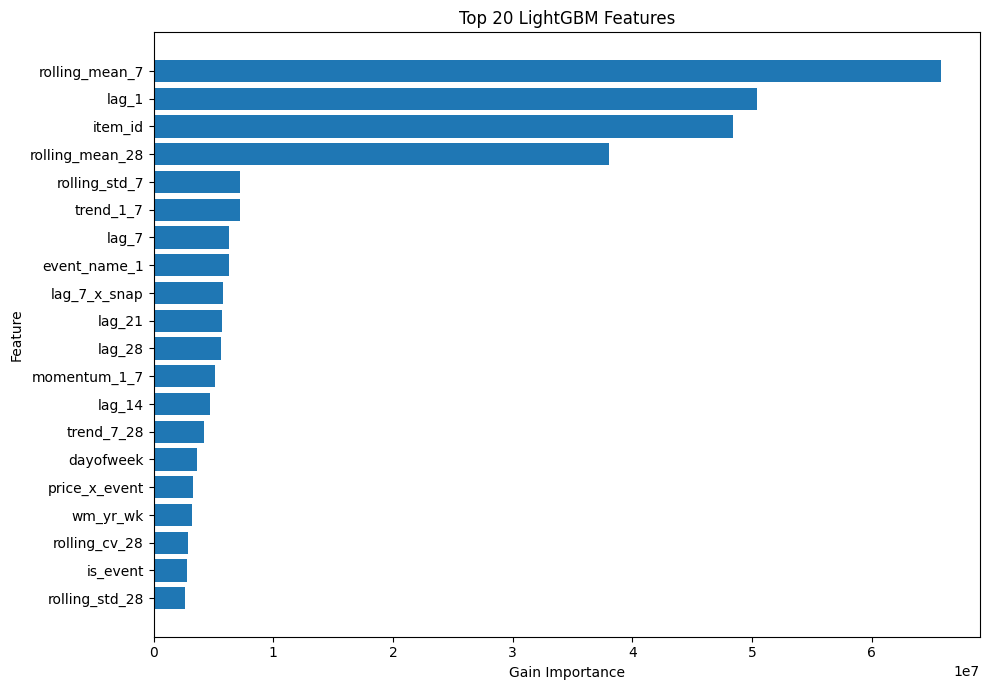

In [4]:
top = importance.head(20).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top["feature"], top["importance"])
plt.xlabel("Gain Importance")
plt.ylabel("Feature")
plt.title("Top 20 LightGBM Features")
plt.tight_layout()
plt.show()